In [1]:
# مرحله 1: کلون کردن مخزن
!git clone https://github.com/mohammadnabia/DA_nnUNet.git

# مرحله 2: وارد فولدر پروژه
%cd DA_nnUNet

# مرحله 3: نصب پروژه در حالت editable
!pip install -e .


Cloning into 'DA_nnUNet'...
remote: Enumerating objects: 310, done.
remote: Counting objects: 100% (310/310), done.
remote: Compressing objects: 100% (278/278), done.
remote: Total 310 (delta 50), reused 276 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (310/310), 2.58 MiB | 17.87 MiB/s, done.
Resolving deltas: 100% (50/50), done.
/content/DA_nnUNet
Obtaining file:///content/DA_nnUNet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/BraTS-peds2023/BraTS-PEDs-2023.zip" -d /content/BraTS_PEDs_2023


In [15]:
import os
import shutil
import json
import glob

source_dir = "/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData"
target_dir = "/content/imagesTs"
os.makedirs(target_dir, exist_ok=True)

with open('/content/drive/MyDrive/100_epoch_Deeper_training_on_bratspeds_finetune/splits_final.json', 'r') as f:
    splits = json.load(f)

val_cases = splits[0]['val']  # Fold 0

for case in val_cases:
    case_path = os.path.join(source_dir, case)
    if not os.path.isdir(case_path):
        continue
    try:
        shutil.copyfile(glob.glob(os.path.join(case_path, "*t1n.nii.gz"))[0], os.path.join(target_dir, f"{case}_0000.nii.gz"))
        shutil.copyfile(glob.glob(os.path.join(case_path, "*t1c.nii.gz"))[0], os.path.join(target_dir, f"{case}_0001.nii.gz"))
        shutil.copyfile(glob.glob(os.path.join(case_path, "*t2w.nii.gz"))[0], os.path.join(target_dir, f"{case}_0002.nii.gz"))
        shutil.copyfile(glob.glob(os.path.join(case_path, "*t2f.nii.gz"))[0], os.path.join(target_dir, f"{case}_0003.nii.gz"))
    except IndexError:
        print(f"⚠️ Missing modalities for case: {case}")

print("✅ Validation fold 0 cases copied to imagesTs.")


✅ Validation fold 0 cases copied to imagesTs.


In [4]:
!mkdir -p /content/nnUNet_results_baseline/Dataset139_BraTS2023/nnUNetTrainer_TL_FTen_Custom_100epochs__nnUNetPlans__3d_fullres/fold_0

# کپی checkpoint
!cp "/content/drive/MyDrive/100_epoch_Deeper_training_on_bratspeds_finetune/fold_0_epoch_100.pth" \
    /content/nnUNet_results_baseline/Dataset139_BraTS2023/nnUNetTrainer_TL_FTen_Custom_100epochs__nnUNetPlans__3d_fullres/fold_0/checkpoint_final.pth

# کپی plans.json
!cp "/content/drive/MyDrive/100_epoch_Deeper_training_on_bratspeds_finetune/nnUNetPlans.json" \
    /content/nnUNet_results_baseline/Dataset139_BraTS2023/nnUNetTrainer_TL_FTen_Custom_100epochs__nnUNetPlans__3d_fullres/plans.json

# کپی dataset.json
!cp "/content/drive/MyDrive/100_epoch_Deeper_training_on_bratspeds_finetune/dataset.json" \
    /content/nnUNet_results_baseline/Dataset139_BraTS2023/nnUNetTrainer_TL_FTen_Custom_100epochs__nnUNetPlans__3d_fullres/

# کپی splits_final.json
!cp "/content/drive/MyDrive/100_epoch_Deeper_training_on_bratspeds_finetune/splits_final.json" \
    /content/nnUNet_results_baseline/Dataset139_BraTS2023/nnUNetTrainer_TL_FTen_Custom_100epochs__nnUNetPlans__3d_fullres/


In [5]:
import os, glob

# مسیر خروجی‌هایی که قبلاً ساختی
PRED_DIR = "/content/drive/MyDrive/nnUNet_Pruned_Results_peds2023/BraTS-PEDS_deeperFT100epoch_80pruned_noTTA"

# مسیر تصاویر ورودی (مودالیتی‌ها)
INPUT_DIR = "/content/imagesTs"

# انتخاب اولین کیس برای نمایش
preds = sorted(glob.glob(os.path.join(PRED_DIR, "*.nii.gz")))
print(f"تعداد خروجی‌های موجود: {len(preds)}")
CASE_ID = os.path.basename(preds[0]).replace(".nii.gz", "")
print("✅ CASE انتخاب‌شده:", CASE_ID)


تعداد خروجی‌های موجود: 20
✅ CASE انتخاب‌شده: BraTS-PED-00008-000


In [6]:
# =========================
# 3D five-views per case (with cut-away layered combined)
# =========================
# نیازمندی‌ها (اگر نصب نیستند):
# !pip -q install nibabel scikit-image matplotlib

import os, glob, numpy as np, nibabel as nib, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure, morphology, filters
from matplotlib.patches import Patch

# ---------- مسیرها ----------
INPUT_DIR = "/content/imagesTs"   # مودالیتی‌ها (T1ce = *_0001.nii.gz)
PRED_DIR  = "/content/drive/MyDrive/nnUNet_Pruned_Results_peds2023/BraTS-PEDS_deeperFT100epoch_80pruned_noTTA"
OUT_DIR   = "/content/final_outputs/3D_five_views_cutaway"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- رنگ‌ها (بدون تغییر آلفا) ----------
COLORS = {
    "ET":    (1.00, 0.00, 0.00, 0.85),  # قرمز
    "TC":    (1.00, 0.60, 0.00, 0.70),  # نارنجی-زرد
    "WT":    (0.00, 1.00, 0.00, 0.55),  # سبز
    "BRAIN": (0.80, 0.80, 0.80, 0.18),  # خاکستری روشن
}
DPI = 420

# ---------- توابع کمکی ----------
def normalize(v):
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    return np.clip((v - lo) / (hi - lo + 1e-6), 0, 1)

def marching(mask, spacing, min_vox=50):
    if mask is None or mask.sum() < min_vox: return None
    v, f, _, _ = measure.marching_cubes(mask.astype(np.uint8), 0.5, spacing=spacing, step_size=1)
    return v, f

def add_mesh(ax, verts, faces, rgba):
    if verts is None or faces is None or len(faces)==0: return
    poly = Poly3DCollection(verts[faces], linewidths=0)
    poly.set_facecolor(rgba)
    ax.add_collection3d(poly)

def setup_ax(ax, vb, elev=10, azim=95, dist=4.8):
    (xmin,ymin,zmin),(xmax,ymax,zmax) = vb.min(0), vb.max(0)
    ax.set_xlim(xmin,xmax); ax.set_ylim(ymin,ymax); ax.set_zlim(zmin,zmax)
    ax.set_box_aspect((xmax-xmin, ymax-ymin, zmax-zmin))
    ax.view_init(elev=elev, azim=azim); ax.dist = dist
    ax.set_axis_off()

def boolean_shells(M_WT, M_TC, M_ET):
    WT_shell = M_WT & ~M_TC
    TC_shell = M_TC & ~M_ET
    ET_shell = M_ET.copy()
    return WT_shell, TC_shell, ET_shell

def cut_faces(verts, faces, y_cut_mm):
    """نگه داشتن نیمه‌ی پشتی (y >= y_cut_mm) برای ایجاد cut-away کورونال."""
    if verts is None or faces is None: return None
    keep = np.all(verts[faces][:,:,1] >= y_cut_mm, axis=1)
    faces_kept = faces[keep]
    if len(faces_kept)==0: return None
    return verts, faces_kept

# ---------- پردازش ۵ کیس ----------
preds = sorted(glob.glob(os.path.join(PRED_DIR, "*.nii.gz")))
print(f"Found {len(preds)} prediction files.")
for pred_path in preds[:5]:
    case_id = os.path.basename(pred_path).replace(".nii.gz", "")
    img_path = os.path.join(INPUT_DIR, f"{case_id}_0001.nii.gz")  # T1ce

    if not os.path.exists(img_path):
        print(f"⚠️ {case_id}: missing T1ce -> skip"); continue

    print(f"🧠 {case_id}")

    # --- بارگذاری ---
    seg = nib.load(pred_path).get_fdata().astype(np.int16)
    img = nib.load(img_path).get_fdata().astype(np.float32)
    aff = nib.load(img_path).affine
    spacing = (abs(aff[0,0]), abs(aff[1,1]), abs(aff[2,2]))

    # --- ماسک‌ها براساس BraTS-PEDs (WT={1,2,3}، TC={2,3}، ET={3}) ---
    def bmask(S): return morphology.binary_dilation(np.isin(seg, list(S)), morphology.ball(1))
    M_WT, M_TC, M_ET = bmask({1,2,3}), bmask({2,3}), bmask({3})

    # --- سطح مغز ---
    norm = normalize(img)
    thr = filters.threshold_otsu(norm)
    brain = morphology.binary_closing(norm > thr*0.9, morphology.ball(1))
    vb, fb, _, _ = measure.marching_cubes(brain.astype(np.uint8), 0.5, spacing=spacing, step_size=1)

    # --- مش‌های تک‌کلاسه ---
    mesh_brain = (vb, fb)
    mesh_wt = marching(M_WT, spacing)
    mesh_tc = marching(M_TC, spacing)
    mesh_et = marching(M_ET, spacing)

    # ========== چهار تصویر تک‌کلاسه ==========
    def save_single(active, title, fname):
        fig = plt.figure(figsize=(7,7), dpi=DPI)
        ax = fig.add_subplot(111, projection='3d')
        if "BRAIN" in active: add_mesh(ax, *mesh_brain, COLORS["BRAIN"])
        if "WT"    in active and mesh_wt: add_mesh(ax, *mesh_wt, COLORS["WT"])
        if "TC"    in active and mesh_tc: add_mesh(ax, *mesh_tc, COLORS["TC"])
        if "ET"    in active and mesh_et: add_mesh(ax, *mesh_et, COLORS["ET"])
        setup_ax(ax, vb)
        ax.set_title(f"{case_id} — {title}", fontsize=11)
        ax.legend(
            handles=[
                Patch(facecolor=COLORS["ET"], label="ET"),
                Patch(facecolor=COLORS["TC"], label="TC"),
                Patch(facecolor=COLORS["WT"], label="WT"),
                Patch(facecolor=COLORS["BRAIN"], label="Brain")
            ],
            loc='lower left', bbox_to_anchor=(0.02,0.02), fontsize=9, framealpha=0.95
        )
        plt.savefig(os.path.join(OUT_DIR, fname), bbox_inches='tight', pad_inches=0.05); plt.close(fig)

    save_single(["BRAIN"],          "3D Brain-only",   f"{case_id}_3D_brain.png")
    save_single(["ET"],             "3D ET-only",      f"{case_id}_3D_ET.png")
    save_single(["TC"],             "3D TC-only",      f"{case_id}_3D_TC.png")
    save_single(["WT"],             "3D WT-only",      f"{case_id}_3D_WT.png")

    # ========== تصویر Combined (cut-away + shells) ==========
    # پوسته‌های غیر هم‌پوشان
    WT_shell, TC_shell, ET_shell = boolean_shells(M_WT, M_TC, M_ET)

    # صفحه‌ی برش از روی centroid تومور (محور y = coronal)
    if M_WT.any():
        y_centroid_idx = int(np.argwhere(M_WT)[:,1].mean())
    else:
        y_centroid_idx = seg.shape[1]//2
    y_cut_mm = y_centroid_idx * spacing[1]

    # مش‌های بریده‌شده
    mesh_wt_cut = cut_faces(*marching(WT_shell, spacing), y_cut_mm) if marching(WT_shell, spacing) else None
    mesh_tc_cut = cut_faces(*marching(TC_shell, spacing), y_cut_mm) if marching(TC_shell, spacing) else None
    mesh_et_cut = cut_faces(*marching(ET_shell, spacing), y_cut_mm) if marching(ET_shell, spacing) else None

    # رسم به ترتیب Brain -> WT_shell -> TC_shell -> ET
    fig = plt.figure(figsize=(7,7), dpi=DPI)
    ax  = fig.add_subplot(111, projection='3d')
    add_mesh(ax, *mesh_brain, COLORS["BRAIN"])
    if mesh_wt_cut: add_mesh(ax, *mesh_wt_cut, COLORS["WT"])
    if mesh_tc_cut: add_mesh(ax, *mesh_tc_cut, COLORS["TC"])
    if mesh_et_cut: add_mesh(ax, *mesh_et_cut, COLORS["ET"])
    setup_ax(ax, vb)
    ax.set_title(f"{case_id} — 3D Combined (cut-away layered)", fontsize=11)
    ax.legend(
        handles=[
            Patch(facecolor=COLORS["ET"], label="ET"),
            Patch(facecolor=COLORS["TC"], label="TC"),
            Patch(facecolor=COLORS["WT"], label="WT"),
            Patch(facecolor=COLORS["BRAIN"], label="Brain")
        ],
        loc='lower left', bbox_to_anchor=(0.02,0.02), fontsize=9, framealpha=0.95
    )
    plt.savefig(os.path.join(OUT_DIR, f"{case_id}_3D_combined.png"), bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

print(f"✅ Done. All figures saved under: {OUT_DIR}")


Found 20 prediction files.
🧠 BraTS-PED-00008-000
🧠 BraTS-PED-00021-000
🧠 BraTS-PED-00026-000
🧠 BraTS-PED-00042-000
🧠 BraTS-PED-00050-000
✅ Done. All figures saved under: /content/final_outputs/3D_five_views_cutaway


In [ ]:
# =========================================
# Make 3D figures for ALL cases & save to Google Drive
# Brain, ET, TC, WT + Combined (cut-away layered)
# =========================================
# !pip -q install nibabel scikit-image matplotlib

import os, glob, time, numpy as np, nibabel as nib, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure, morphology, filters
from matplotlib.patches import Patch

# ---------- Mount Google Drive ----------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print("Colab drive mount skipped (local env).")

# ---------- Paths ----------
INPUT_DIR = "/content/imagesTs"   # modalities (BraTS-PEDs: *_000{0,1,2,3}.nii.gz)
PRED_DIR  = "/content/drive/MyDrive/nnUNet_Pruned_Results_peds2023/BraTS-PEDS_deeperFT100epoch_80pruned_noTTA"
DRIVE_OUT_ROOT = "/content/drive/MyDrive"
OUT_DIR  = os.path.join(DRIVE_OUT_ROOT, "BraTS_3D_All_Cases_cutaway")
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Colors (fixed) ----------
COLORS = {
    "ET":    (1.00, 0.00, 0.00, 0.85),  # Red
    "TC":    (1.00, 0.60, 0.00, 0.70),  # Orange-Yellow
    "WT":    (0.00, 1.00, 0.00, 0.55),  # Green
    "BRAIN": (0.80, 0.80, 0.80, 0.18),  # Light gray
}
DPI = 420

# ---------- Helpers ----------
def normalize(v):
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    return np.clip((v - lo) / (hi - lo + 1e-6), 0, 1)

def marching(mask, spacing, min_vox=50):
    if mask is None or mask.sum() < min_vox: return None
    v, f, _, _ = measure.marching_cubes(mask.astype(np.uint8), 0.5, spacing=spacing, step_size=1)
    return v, f

def add_mesh(ax, verts, faces, rgba):
    if verts is None or faces is None or len(faces)==0: return
    poly = Poly3DCollection(verts[faces], linewidths=0)
    poly.set_facecolor(rgba)
    ax.add_collection3d(poly)

def setup_ax(ax, vb, elev=10, azim=95, dist=4.8):
    (xmin,ymin,zmin),(xmax,ymax,zmax) = vb.min(0), vb.max(0)
    ax.set_xlim(xmin,xmax); ax.set_ylim(ymin,ymax); ax.set_zlim(zmin,zmax)
    ax.set_box_aspect((xmax-xmin, ymax-ymin, zmax-zmin))
    ax.view_init(elev=elev, azim=azim); ax.dist = dist
    ax.set_axis_off()

def boolean_shells(M_WT, M_TC, M_ET):
    WT_shell = M_WT & ~M_TC
    TC_shell = M_TC & ~M_ET
    ET_shell = M_ET.copy()
    return WT_shell, TC_shell, ET_shell

def cut_faces(verts, faces, y_cut_mm):
    """Keep posterior half (y >= y_cut_mm) for coronal cut-away."""
    if verts is None or faces is None: return None
    keep = np.all(verts[faces][:,:,1] >= y_cut_mm, axis=1)
    faces_kept = faces[keep]
    if len(faces_kept)==0: return None
    return verts, faces_kept

def pick_modality(case_id):
    """Prefer T1ce (_0001), then FLAIR (_0003), T2 (_0002), T1 (_0000)."""
    for suf in ["_0001.nii.gz","_0003.nii.gz","_0002.nii.gz","_0000.nii.gz"]:
        p = os.path.join(INPUT_DIR, f"{case_id}{suf}")
        if os.path.exists(p): return p
    return None

# ---------- Gather predictions ----------
preds = sorted(glob.glob(os.path.join(PRED_DIR, "*.nii.gz")))
print(f"🔎 تعداد کیس‌های پیدا شده در PRED_DIR: {len(preds)}")

if not preds:
    raise SystemExit("هیچ فایل پیش‌بینی (.nii.gz) در PRED_DIR پیدا نشد.")

# ---------- Process all cases ----------
t0_all = time.time()
done, skipped = 0, 0

for i, pred_path in enumerate(preds, 1):
    try:
        case_id = os.path.basename(pred_path).replace(".nii.gz", "")
        img_path = pick_modality(case_id)
        if img_path is None:
            print(f"⚠️ {i}/{len(preds)} {case_id}: هیچ مودالیتی (0000..0003) پیدا نشد → پرش")
            skipped += 1; continue

        out_case = os.path.join(OUT_DIR, case_id)
        os.makedirs(out_case, exist_ok=True)

        print(f"🧠 {i}/{len(preds)}  {case_id}  |  modality: {os.path.basename(img_path)}")

        # --- Load volumes ---
        seg = nib.load(pred_path).get_fdata().astype(np.int16)
        img = nib.load(img_path).get_fdata().astype(np.float32)
        aff = nib.load(img_path).affine
        spacing = (abs(aff[0,0]), abs(aff[1,1]), abs(aff[2,2]))

        # --- Masks (BraTS-PEDs) ---
        def bmask(S): return morphology.binary_dilation(np.isin(seg, list(S)), morphology.ball(1))
        M_WT, M_TC, M_ET = bmask({1,2,3}), bmask({2,3}), bmask({3})

        # --- Brain surface ---
        norm = normalize(img)
        thr = filters.threshold_otsu(norm)
        brain = morphology.binary_closing(norm > thr*0.9, morphology.ball(1))
        vb, fb, _, _ = measure.marching_cubes(brain.astype(np.uint8), 0.5, spacing=spacing, step_size=1)

        # --- Single-class meshes ---
        mesh_brain = (vb, fb)
        mesh_wt = marching(M_WT, spacing)
        mesh_tc = marching(M_TC, spacing)
        mesh_et = marching(M_ET, spacing)

        # ===== 4 single renders =====
        def save_single(active, title, fname):
            fig = plt.figure(figsize=(7,7), dpi=DPI)
            ax = fig.add_subplot(111, projection='3d')
            if "BRAIN" in active: add_mesh(ax, *mesh_brain, COLORS["BRAIN"])
            if "WT"    in active and mesh_wt: add_mesh(ax, *mesh_wt, COLORS["WT"])
            if "TC"    in active and mesh_tc: add_mesh(ax, *mesh_tc, COLORS["TC"])
            if "ET"    in active and mesh_et: add_mesh(ax, *mesh_et, COLORS["ET"])
            setup_ax(ax, vb)
            ax.set_title(f"{case_id} — {title}", fontsize=11)
            ax.legend(
                handles=[
                    Patch(facecolor=COLORS["ET"], label="ET"),
                    Patch(facecolor=COLORS["TC"], label="TC"),
                    Patch(facecolor=COLORS["WT"], label="WT"),
                    Patch(facecolor=COLORS["BRAIN"], label="Brain")
                ],
                loc='lower left', bbox_to_anchor=(0.02,0.02), fontsize=9, framealpha=0.95
            )
            plt.savefig(os.path.join(out_case, fname), bbox_inches='tight', pad_inches=0.05); plt.close(fig)

        save_single(["BRAIN"], "3D Brain-only",   f"{case_id}_3D_brain.png")
        save_single(["ET"],    "3D ET-only",      f"{case_id}_3D_ET.png")
        save_single(["TC"],    "3D TC-only",      f"{case_id}_3D_TC.png")
        save_single(["WT"],    "3D WT-only",      f"{case_id}_3D_WT.png")

        # ===== Combined: cut-away + shells =====
        WT_shell, TC_shell, ET_shell = boolean_shells(M_WT, M_TC, M_ET)
        if M_WT.any():
            y_centroid_idx = int(np.argwhere(M_WT)[:,1].mean())
        else:
            y_centroid_idx = seg.shape[1]//2
        y_cut_mm = y_centroid_idx * spacing[1]

        def mesh_cut(mask):
            m = marching(mask, spacing)
            return None if m is None else cut_faces(*m, y_cut_mm)

        mesh_wt_cut = mesh_cut(WT_shell)
        mesh_tc_cut = mesh_cut(TC_shell)
        mesh_et_cut = mesh_cut(ET_shell)

        fig = plt.figure(figsize=(7,7), dpi=DPI)
        ax  = fig.add_subplot(111, projection='3d')
        add_mesh(ax, *mesh_brain, COLORS["BRAIN"])
        if mesh_wt_cut: add_mesh(ax, *mesh_wt_cut, COLORS["WT"])
        if mesh_tc_cut: add_mesh(ax, *mesh_tc_cut, COLORS["TC"])
        if mesh_et_cut: add_mesh(ax, *mesh_et_cut, COLORS["ET"])
        setup_ax(ax, vb)
        ax.set_title(f"{case_id} — 3D Combined (cut-away layered)", fontsize=11)
        ax.legend(
            handles=[
                Patch(facecolor=COLORS["ET"], label="ET"),
                Patch(facecolor=COLORS["TC"], label="TC"),
                Patch(facecolor=COLORS["WT"], label="WT"),
                Patch(facecolor=COLORS["BRAIN"], label="Brain")
            ],
            loc='lower left', bbox_to_anchor=(0.02,0.02), fontsize=9, framealpha=0.95
        )
        plt.savefig(os.path.join(out_case, f"{case_id}_3D_combined.png"), bbox_inches='tight', pad_inches=0.05)
        plt.close(fig)

        done += 1
    except Exception as e:
        print(f"❌ خطا در {pred_path}: {e}")
        skipped += 1

t_elapsed = time.time() - t0_all
print(f"\n✅ پایان کار. ساخته شد: {done} کیس  |  پرش: {skipped}  |  زمان: {t_elapsed:.1f}s")
print(f"📁 همهٔ خروجی‌ها در این پوشهٔ Drive ذخیره شدند:\n{OUT_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔎 تعداد کیس‌های پیدا شده در PRED_DIR: 20
🧠 1/20  BraTS-PED-00008-000  |  modality: BraTS-PED-00008-000_0001.nii.gz
🧠 2/20  BraTS-PED-00021-000  |  modality: BraTS-PED-00021-000_0001.nii.gz
🧠 3/20  BraTS-PED-00026-000  |  modality: BraTS-PED-00026-000_0001.nii.gz
🧠 4/20  BraTS-PED-00042-000  |  modality: BraTS-PED-00042-000_0001.nii.gz
🧠 5/20  BraTS-PED-00050-000  |  modality: BraTS-PED-00050-000_0001.nii.gz
🧠 6/20  BraTS-PED-00055-000  |  modality: BraTS-PED-00055-000_0001.nii.gz
🧠 7/20  BraTS-PED-00063-000  |  modality: BraTS-PED-00063-000_0001.nii.gz
🧠 8/20  BraTS-PED-00078-000  |  modality: BraTS-PED-00078-000_0001.nii.gz
🧠 9/20  BraTS-PED-00079-000  |  modality: BraTS-PED-00079-000_0001.nii.gz
🧠 10/20  BraTS-PED-00084-000  |  modality: BraTS-PED-00084-000_0001.nii.gz
🧠 11/20  BraTS-PED-00086-000  |  modality: BraTS-PED-00086-000_0001.nii.gz
🧠 12/20  BraTS

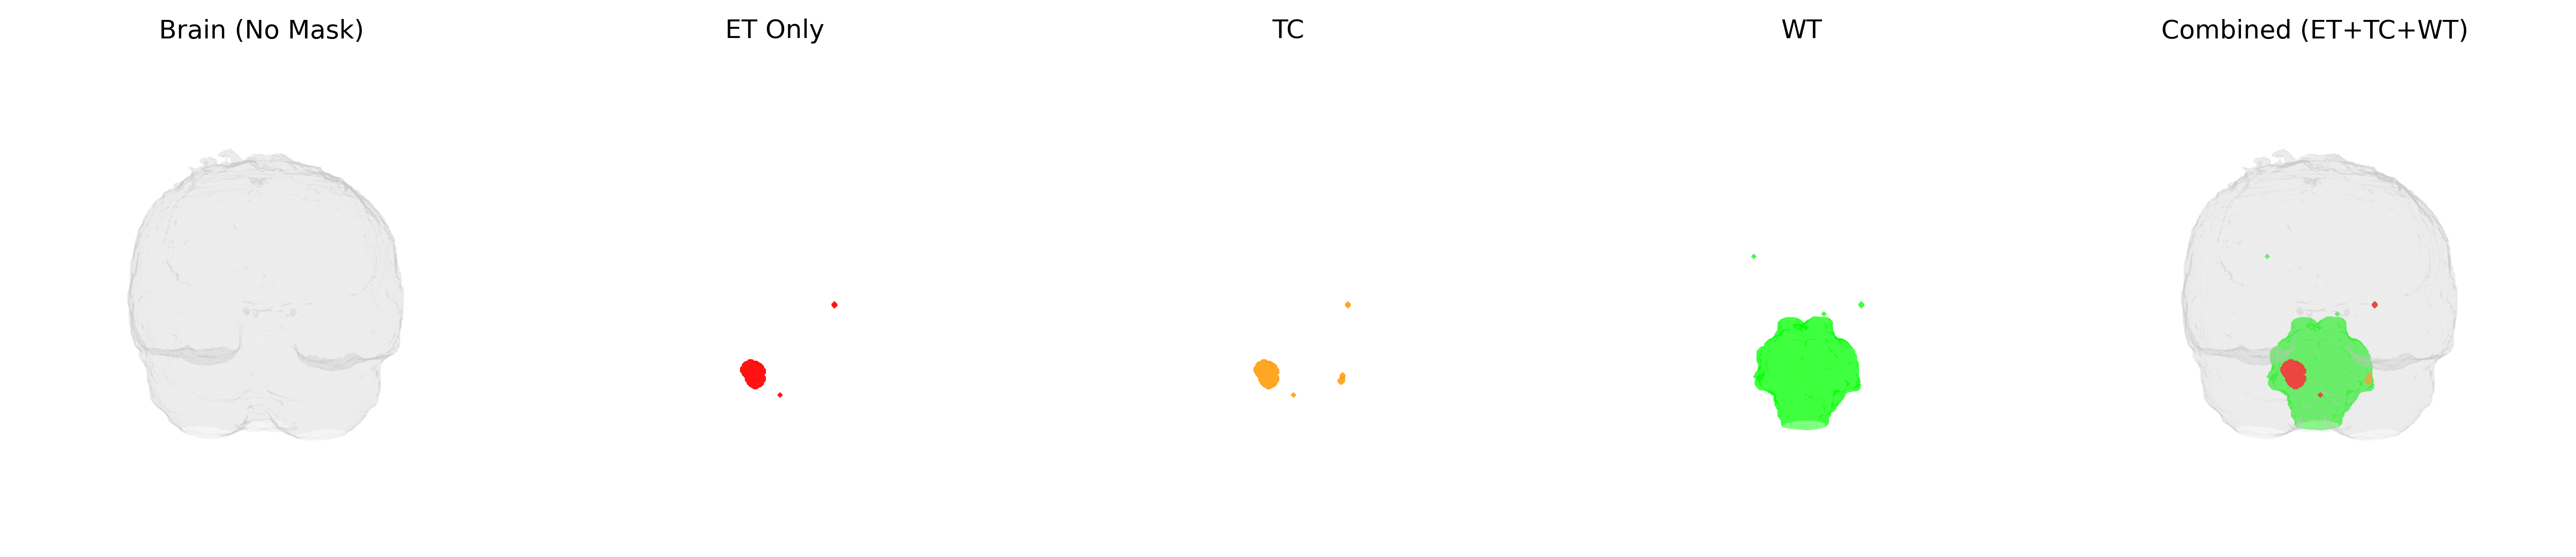

✅ تصویر Ground Truth ساخته شد و ذخیره گردید در: /content/gt_BraTS-PED-00096-000_3D.png


In [20]:
# =========================================
# 3D Visualization for Ground Truth (BraTS-PEDs)
# Case: BraTS-PED-00086-000
# =========================================

import os, numpy as np, nibabel as nib, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure, morphology, filters
from matplotlib.patches import Patch

# ---------- Path ----------
CASE_DIR = "/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData/BraTS-PED-00096-000"
OUT_PATH = "/content/gt_BraTS-PED-00096-000_3D.png"

# ---------- Colors ----------
COLORS = {
    "ET":    (1.00, 0.00, 0.00, 0.85),  # Red
    "TC":    (1.00, 0.60, 0.00, 0.70),  # Orange
    "WT":    (0.00, 1.00, 0.00, 0.55),  # Green
    "BRAIN": (0.80, 0.80, 0.80, 0.18),  # Light gray
}
DPI = 400

# ---------- Utility Functions ----------
def normalize(v):
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    return np.clip((v - lo) / (hi - lo + 1e-6), 0, 1)

def marching(mask, spacing, min_vox=50):
    if mask is None or mask.sum() < min_vox:
        return None
    v, f, _, _ = measure.marching_cubes(mask.astype(np.uint8), 0.5, spacing=spacing, step_size=1)
    return v, f

def add_mesh(ax, verts, faces, rgba):
    if verts is None or faces is None or len(faces) == 0:
        return
    poly = Poly3DCollection(verts[faces], linewidths=0)
    poly.set_facecolor(rgba)
    ax.add_collection3d(poly)

def setup_ax(ax, vb, elev=10, azim=95, dist=4.8):
    (xmin, ymin, zmin), (xmax, ymax, zmax) = vb.min(0), vb.max(0)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)
    ax.set_box_aspect((xmax - xmin, ymax - ymin, zmax - zmin))
    ax.view_init(elev=elev, azim=azim)
    ax.dist = dist
    ax.set_axis_off()

# ---------- Load data ----------
img_path = [os.path.join(CASE_DIR, f) for f in os.listdir(CASE_DIR) if f.endswith("-t1n.nii.gz")][0]
seg_path = [os.path.join(CASE_DIR, f) for f in os.listdir(CASE_DIR) if f.endswith("-seg.nii.gz")][0]

img = nib.load(img_path).get_fdata().astype(np.float32)
seg = nib.load(seg_path).get_fdata().astype(np.int16)
aff = nib.load(img_path).affine
spacing = (abs(aff[0,0]), abs(aff[1,1]), abs(aff[2,2]))

# ---------- Create Masks (BraTS-PEDs 2023 label definitions) ----------
# Labels: 1=NCR/NET, 2=ED, 3=ET
M_WT = morphology.binary_dilation(np.isin(seg, [1, 2, 3]), morphology.ball(1))  # Whole Tumor
M_TC = morphology.binary_dilation(np.isin(seg, [2, 3]), morphology.ball(1))     # Tumor Core
M_ET = morphology.binary_dilation(seg == 3, morphology.ball(1))                 # Enhancing Tumor


# ---------- Brain mask ----------
norm = normalize(img)
thr = filters.threshold_otsu(norm)
brain = morphology.binary_closing(norm > thr * 0.9, morphology.ball(1))
vb, fb, _, _ = measure.marching_cubes(brain.astype(np.uint8), 0.5, spacing=spacing, step_size=1)

# ---------- Meshes ----------
mesh_brain = (vb, fb)
mesh_wt = marching(M_WT, spacing)
mesh_tc = marching(M_TC, spacing)
mesh_et = marching(M_ET, spacing)

# ---------- Render ----------
fig = plt.figure(figsize=(14, 4), dpi=DPI)
titles = ["Brain (No Mask)", "ET Only", "TC", "WT", "Combined (ET+TC+WT)"]
layers = [["BRAIN"], ["ET"], ["TC"], ["WT"], ["BRAIN", "WT", "TC", "ET"]]

for i, (title, active) in enumerate(zip(titles, layers), 1):
    ax = fig.add_subplot(1, 5, i, projection="3d")
    if "BRAIN" in active: add_mesh(ax, *mesh_brain, COLORS["BRAIN"])
    if "WT" in active and mesh_wt: add_mesh(ax, *mesh_wt, COLORS["WT"])
    if "TC" in active and mesh_tc: add_mesh(ax, *mesh_tc, COLORS["TC"])
    if "ET" in active and mesh_et: add_mesh(ax, *mesh_et, COLORS["ET"])
    setup_ax(ax, vb)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig(OUT_PATH, bbox_inches="tight", pad_inches=0.05)
plt.show()

print(f"✅ تصویر Ground Truth ساخته شد و ذخیره گردید در: {OUT_PATH}")


In [17]:
import nibabel as nib, numpy as np
seg = nib.load("/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData/BraTS-PED-00086-000/BraTS-PED-00086-000-seg.nii.gz").get_fdata()
unique, counts = np.unique(seg, return_counts=True)
print(dict(zip(unique, counts)))


{np.float64(0.0): np.int64(8866137), np.float64(1.0): np.int64(61806), np.float64(3.0): np.int64(57)}


In [18]:
import nibabel as nib
import numpy as np

seg_path = "/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData/BraTS-PED-00096-000/BraTS-PED-00096-000-seg.nii.gz"

seg = nib.load(seg_path).get_fdata()
unique, counts = np.unique(seg, return_counts=True)
voxel_stats = dict(zip(unique, counts))

print("🔍 توزیع برچسب‌ها در BraTS-PED-00096-000:")
for k, v in voxel_stats.items():
    print(f"Label {int(k)} : {v:,} voxels")

total_voxels = seg.size
for k, v in voxel_stats.items():
    print(f" → Label {int(k)} = {100*v/total_voxels:.4f}% از کل حجم")


🔍 توزیع برچسب‌ها در BraTS-PED-00096-000:
Label 0 : 8,878,135 voxels
Label 1 : 49,039 voxels
Label 2 : 11 voxels
Label 3 : 815 voxels
 → Label 0 = 99.4415% از کل حجم
 → Label 1 = 0.5493% از کل حجم
 → Label 2 = 0.0001% از کل حجم
 → Label 3 = 0.0091% از کل حجم


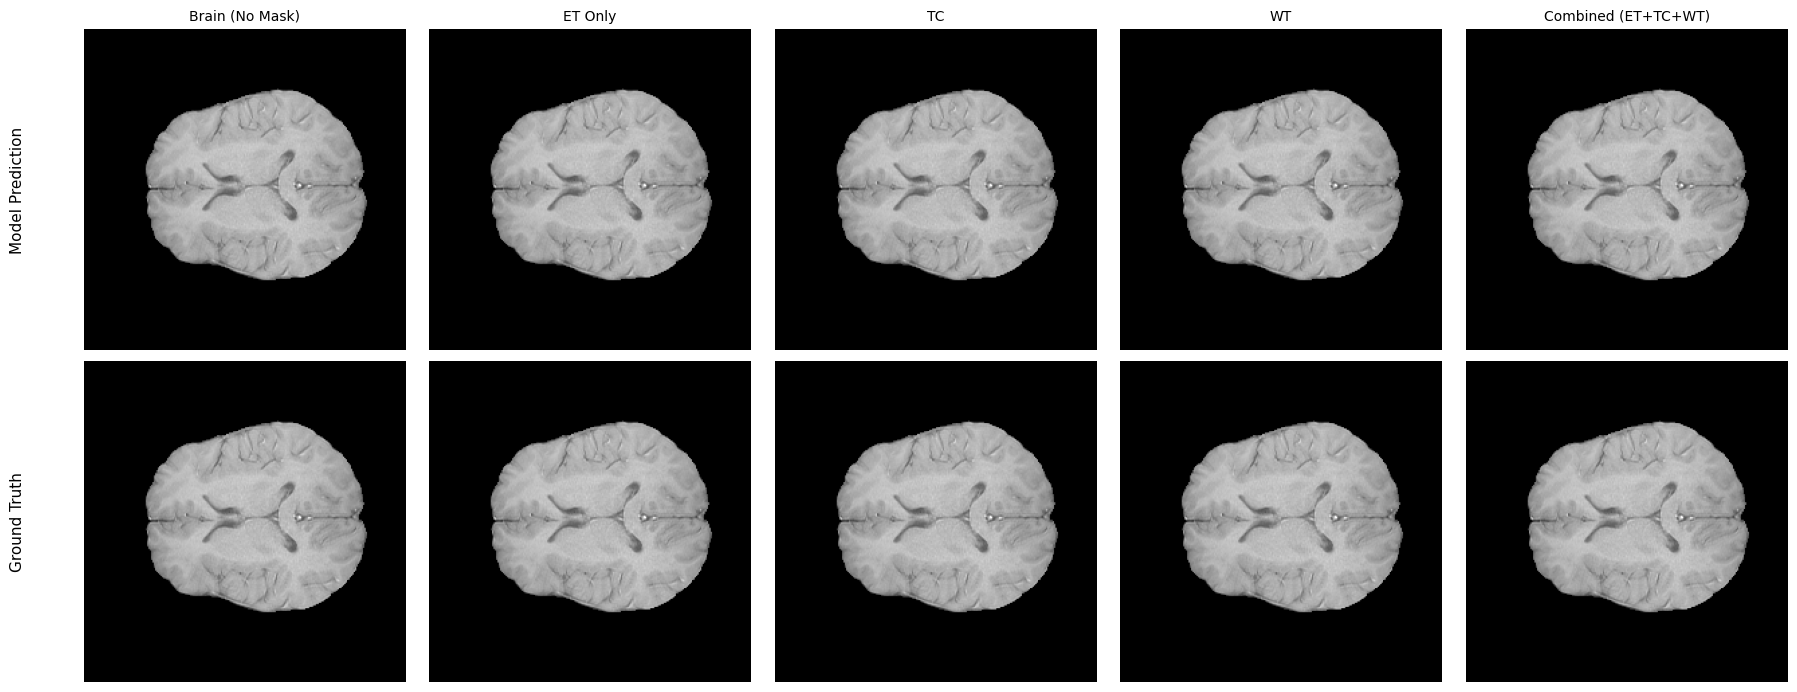

✅ خروجی دوبعدی نهایی ساخته شد: /content/BraTS-PED-00096-000_2D_PRED_vs_GT_fullgrid.png


In [22]:
# =========================================
# 2D Visualization (Prediction vs Ground Truth)
# Columns: Brain | ET | TC | WT | Combined
# Rows: Prediction (Top) & Ground Truth (Bottom)
# =========================================

import os, numpy as np, nibabel as nib, matplotlib.pyplot as plt
from skimage import morphology, filters

# ---------- Paths ----------
CASE_ID = "BraTS-PED-00096-000"

GT_PATH = f"/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData/{CASE_ID}/{CASE_ID}-seg.nii.gz"
IMG_PATH = f"/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData/{CASE_ID}/{CASE_ID}-t1n.nii.gz"
PRED_PATH = f"/content/drive/MyDrive/nnUNet_Pruned_Results_peds2023/BraTS-PEDS_deeperFT100epoch_80pruned_noTTA/{CASE_ID}.nii.gz"

OUT_PATH = f"/content/{CASE_ID}_2D_PRED_vs_GT_fullgrid.png"

# ---------- Load ----------
img = nib.load(IMG_PATH).get_fdata()
gt  = nib.load(GT_PATH).get_fdata().astype(np.int16)
pred = nib.load(PRED_PATH).get_fdata().astype(np.int16)

# ---------- Slice ----------
z = img.shape[2] // 2
img_slice = img[:, :, z]
gt_slice = gt[:, :, z]
pred_slice = pred[:, :, z]

# ---------- Normalize MRI ----------
img_norm = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + 1e-6)

# ---------- Mask definitions (BraTS-PEDs 2023: 1=NCR/NET, 2=ED, 3=ET) ----------
def make_masks(seg):
    M_WT = morphology.binary_dilation(np.isin(seg, [1, 2, 3]), morphology.disk(1))
    M_TC = morphology.binary_dilation(np.isin(seg, [2, 3]), morphology.disk(1))
    M_ET = morphology.binary_dilation(seg == 3, morphology.disk(1))
    return M_WT, M_TC, M_ET

gt_WT, gt_TC, gt_ET = make_masks(gt_slice)
pr_WT, pr_TC, pr_ET = make_masks(pred_slice)

# ---------- Overlay function ----------
def overlay(base, mask, color, alpha=0.4):
    img_rgb = np.stack([base]*3, axis=-1)
    overlay = img_rgb.copy()
    for c in range(3):
        overlay[..., c] = np.where(mask, color[c]*alpha + img_rgb[..., c]*(1-alpha), img_rgb[..., c])
    return overlay

# ---------- Colors ----------
COLORS = {
    "ET": (1.0, 0.0, 0.0),    # Red
    "TC": (1.0, 0.6, 0.0),    # Orange
    "WT": (0.0, 1.0, 0.0),    # Green
}

# ---------- Compose overlays ----------
def make_all_views(seg_ET, seg_TC, seg_WT):
    brain = np.stack([img_norm]*3, axis=-1)
    et = overlay(img_norm, seg_ET, COLORS["ET"])
    tc = overlay(img_norm, seg_TC, COLORS["TC"])
    wt = overlay(img_norm, seg_WT, COLORS["WT"])

    # Combined: overlay in proper order (WT → TC → ET)
    combined = overlay(img_norm, seg_WT, COLORS["WT"], 0.35)
    combined = overlay(combined[...,0], seg_TC, COLORS["TC"], 0.45)
    combined = overlay(combined[...,0], seg_ET, COLORS["ET"], 0.6)
    return [brain, et, tc, wt, combined]

views_pred = make_all_views(pr_ET, pr_TC, pr_WT)
views_gt   = make_all_views(gt_ET, gt_TC, gt_WT)

# ---------- Plot grid ----------
titles = ["Brain (No Mask)", "ET Only", "TC", "WT", "Combined (ET+TC+WT)"]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for j, (row, label) in enumerate(zip([views_pred, views_gt], ["Model Prediction", "Ground Truth"])):
    for i, (img_view, title) in enumerate(zip(row, titles)):
        ax = axes[j, i]
        ax.imshow(img_view)
        ax.axis('off')
        if j == 0: ax.set_title(title, fontsize=10)
        if i == 0: ax.text(-50, img_slice.shape[0]//2, label, fontsize=11, rotation=90, va='center', ha='center')

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ خروجی دوبعدی نهایی ساخته شد: {OUT_PATH}")


In [24]:
z = int(np.round(np.mean(np.argwhere(gt > 0)[:, 2])))
print("Selected central tumor slice:", z)


Selected central tumor slice: 29


In [29]:
# =========================================
# 2D Visualization (Prediction vs Ground Truth)
# Columns: Brain | ET | TC | WT | Combined
# Rows: Prediction (Top) & Ground Truth (Bottom)
# Tumor-centered slice selection + correct RGB overlay
# =========================================

import os, numpy as np, nibabel as nib, matplotlib.pyplot as plt
from skimage import morphology

# ---------- Config ----------
COLORS = {
    "ET": (1.0, 0.0, 0.0),   # Red
    "TC": (1.0, 0.6, 0.0),   # Orange
    "WT": (0.0, 1.0, 0.0),   # Green
}
DPI = 350

def normalize01(v):
    v = v.astype(np.float32)
    vmin, vmax = np.percentile(v, 1), np.percentile(v, 99)
    v = np.clip((v - vmin) / (vmax - vmin + 1e-6), 0, 1)
    return v

def make_masks_2d(seg2d):
    """BraTS-PEDs 2023: 1=NCR/NET, 2=ED, 3=ET"""
    M_WT = morphology.binary_dilation(np.isin(seg2d, [1, 2, 3]), morphology.disk(1))
    M_TC = morphology.binary_dilation(np.isin(seg2d, [2, 3]), morphology.disk(1))
    M_ET = morphology.binary_dilation(seg2d == 3,           morphology.disk(1))
    return M_WT, M_TC, M_ET

def overlay_gray(base_gray, mask, color_rgb, alpha=0.45):
    """Overlay mask on grayscale base -> returns RGB"""
    base_rgb = np.stack([base_gray]*3, axis=-1)
    out = base_rgb.copy()
    for c in range(3):
        out[..., c] = np.where(mask, color_rgb[c]*alpha + base_rgb[..., c]*(1-alpha), base_rgb[..., c])
    return out

def overlay_rgb(base_rgb, mask, color_rgb, alpha=0.45):
    """Overlay mask on RGB base (keeps previous colors) -> returns RGB"""
    out = base_rgb.copy()
    for c in range(3):
        out[..., c] = np.where(mask, color_rgb[c]*alpha + out[..., c]*(1-alpha), out[..., c])
    return out

def pick_tumor_center_slice(seg3d):
    """Pick axial slice near tumor center; fallback to middle slice."""
    idx = np.argwhere(seg3d > 0)
    if idx.size == 0:                           # no tumor
        return seg3d.shape[2] // 2
    return int(np.round(idx[:, 2].mean()))      # center of mass along z

def make_views_for_slice(img2d, seg2d):
    """Return [Brain, ET, TC, WT, Combined] RGB views for a single 2D slice."""
    img_norm = normalize01(img2d)
    M_WT, M_TC, M_ET = make_masks_2d(seg2d)

    brain = np.stack([img_norm]*3, axis=-1)
    et    = overlay_gray(img_norm, M_ET, COLORS["ET"], 0.55)
    tc    = overlay_gray(img_norm, M_TC, COLORS["TC"], 0.45)
    wt    = overlay_gray(img_norm, M_WT, COLORS["WT"], 0.35)

    # Combined in correct order: WT -> TC -> ET (keep previous colors)
    combined = overlay_rgb(brain, M_WT, COLORS["WT"], 0.35)
    combined = overlay_rgb(combined, M_TC, COLORS["TC"], 0.45)
    combined = overlay_rgb(combined, M_ET, COLORS["ET"], 0.60)

    return [brain, et, tc, wt, combined]

def plot_2D_comparison(
    case_id: str,
    base_dir="/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData",
    pred_dir="/content/drive/MyDrive/nnUNet_Pruned_Results_peds2023/BraTS-PEDS_deeperFT100epoch_80pruned_noTTA",
    modality_suffix="-t1n.nii.gz",
    save_dir="/content"
):
    """Build 2x5 grid: top=Prediction, bottom=GT; columns=Brain/ET/TC/WT/Combined."""
    gt_path   = os.path.join(base_dir, case_id, f"{case_id}-seg.nii.gz")
    img_path  = os.path.join(base_dir, case_id, f"{case_id}{modality_suffix}")
    pred_path = os.path.join(pred_dir, f"{case_id}.nii.gz")
    out_path  = os.path.join(save_dir, f"{case_id}_2D_PRED_vs_GT_fullgrid.png")

    # Load
    img  = nib.load(img_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata().astype(np.int16)
    pred = nib.load(pred_path).get_fdata().astype(np.int16)

    # Choose slice
    z = pick_tumor_center_slice(gt)
    print(f"🧠 {case_id} | axial slice z = {z}")

    img2d  = img[:, :, z]
    gt2d   = gt[:,  :, z]
    pred2d = pred[:, :, z]

    # Make views
    views_pred = make_views_for_slice(img2d, pred2d)
    views_gt   = make_views_for_slice(img2d, gt2d)

    # Plot
    titles = ["Brain (No Mask)", "ET Only", "TC", "WT", "Combined (ET+TC+WT)"]
    fig, axes = plt.subplots(2, 5, figsize=(18, 7), dpi=DPI)

    for j, (row, row_label) in enumerate(zip([views_pred, views_gt], ["Model Prediction", "Ground Truth"])):
        for i, (view, title) in enumerate(zip(row, titles)):
            ax = axes[j, i]
            ax.imshow(view)
            ax.axis("off")
            if j == 0:
                ax.set_title(title, fontsize=10)
            if i == 0:
                ax.text(-40, img2d.shape[0]//2, row_label, fontsize=11, rotation=90,
                        va='center', ha='center')

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", pad_inches=0.05)
    plt.show()
    print(f"✅ Saved: {out_path}")

# ---------- Example ----------
# plot_2D_comparison("BraTS-PED-00096-000")


🧠 BraTS-PED-00096-000 | axial slice z = 29


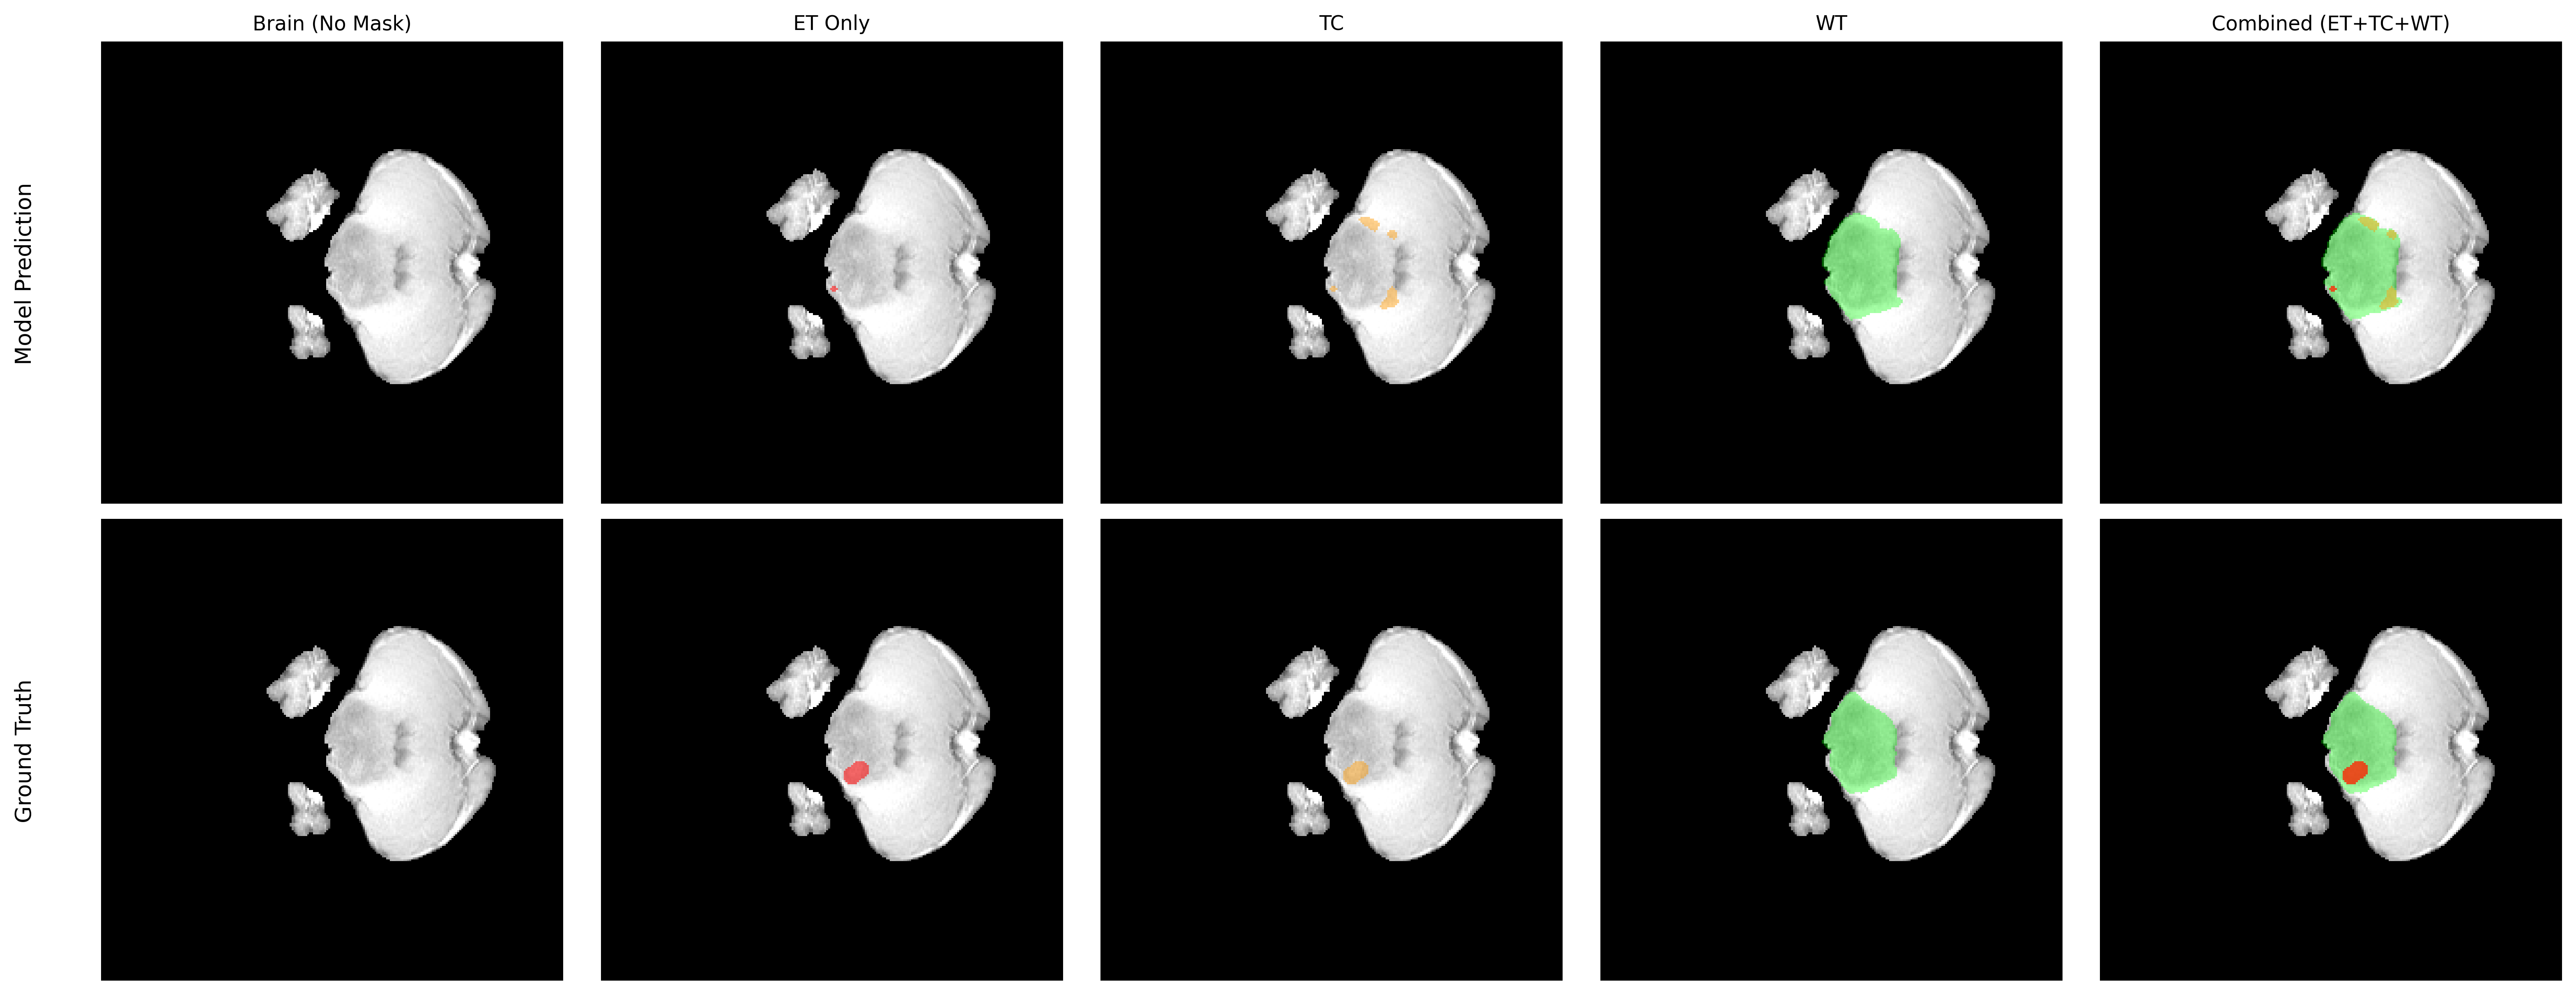

✅ Saved: /content/BraTS-PED-00096-000_2D_PRED_vs_GT_fullgrid.png


In [30]:
plot_2D_comparison("BraTS-PED-00096-000")
